# Final Projesi — Geçerleme, Test ve Demo

Bu defter, final ödevi yönergesinin 7. bölümü gereği **model geçerleme, test ve demo
kodlarını** tek yerde toplar. Tüm sayılar `final/run_experiment.py` ve `final/improve.py`
tarafından üretilen kayıtlı çıktılardan gelir; test bölümü, kaydedilen modelleri yeniden
değerlendirerek sonuçların **tekrar üretilebilir** olduğunu gösterir.

Çalıştırma: depo kökünde `jupyter notebook final/SONUCLAR_VE_DEMO.ipynb`
(önce `final/run_experiment.py` ve `final/improve.py` koşulmuş olmalı).

In [1]:
import json
import sys
from pathlib import Path

KOK = Path.cwd()
if KOK.name == 'final':          # defter final/ içinden açılırsa köke çık
    KOK = KOK.parent
sys.path.insert(0, str(KOK))
import os
os.chdir(KOK)

import numpy as np
import pandas as pd
import torch

from final.pipeline import SplitSettings, _feature_folds
from final.predict import load_checkpoint
from final.training import evaluate_arrays, inverse_frequency_weights
from ser.constants import NUM_CLASSES
from ser.data.splits import prepare_splits

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CIKTI = Path('final/outputs/cremad')
print('Cihaz:', device)

Cihaz: cuda


## 1. Geçerleme (validation) sonuçları

Her iki yöntem için hiperparametre araması yalnızca geçerleme kümesinde yapıldı
(seçim ölçütü: macro-F1). Aşağıda her yöntemin en iyi 5 adayı ve kazanan
yapılandırma görülüyor.

In [2]:
for yontem in ('cnn', 'rnn'):
    log = pd.read_csv(CIKTI / yontem / 'search_log.csv')
    print(f"=== {yontem.upper()} — {len(log)} deneme (arama + yerel iyileştirme) ===")
    goster = (log.sort_values('val_macro_f1', ascending=False)
                 .head(5)[['stage', 'val_accuracy', 'val_macro_f1', 'best_epoch', 'seconds']])
    display(goster.reset_index(drop=True))
    kazanan = json.loads((CIKTI / yontem / 'winner.json').read_text(encoding='utf-8'))
    print('Kazanan öznitelik:', kazanan['feature_config'])
    print('Kazanan model   :', kazanan['model_config'])
    print()

=== CNN — 19 deneme (arama + yerel iyileştirme) ===


,stage,val_accuracy,val_macro_f1,best_epoch,seconds
0,refine,0.557491,0.553080,29,42.7
1,refine,0.560105,0.552799,14,16.7
2,refine,0.552265,0.549461,19,35.3
3,refine,0.550523,0.544550,14,17.0
4,refine,0.546167,0.544084,25,25.0


Kazanan öznitelik: {'sample_rate': 16000, 'n_mels': 64, 'n_frames': 128, 'n_fft': 1024, 'hop_length': 256, 'fmin': 20.0, 'fmax': 8000.0, 'top_db': 80.0}
Kazanan model   : {'channels': [32, 64, 128], 'dropout': 0.3, 'optim': {'batch_size': 16, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'patience': 8}}

=== RNN — 25 deneme (arama + yerel iyileştirme) ===


,stage,val_accuracy,val_macro_f1,best_epoch,seconds
0,refine,0.563589,0.563814,9,8.0
1,refine,0.561847,0.561945,9,7.1
2,refine,0.567073,0.561289,11,7.9
3,search,0.566202,0.561184,10,7.6
4,search,0.560105,0.559887,14,10.5


Kazanan öznitelik: {'sample_rate': 16000, 'n_intervals': 32, 'interval_ms': 200, 'n_mfcc': 13, 'n_fft': 512, 'hop_length': 160}
Kazanan model   : {'rnn_type': 'gru', 'hidden_size': 192, 'num_layers': 2, 'bidirectional': True, 'dropout': 0.3, 'pooling': 'mean', 'optim': {'batch_size': 64, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'patience': 8}}



## 2. Test sonuçlarının yeniden üretimi (tekrarlanabilirlik)

Kaydedilen kazanan modeller yüklenip test kümesi **yeniden** değerlendiriliyor ve
sonuç, deney sırasında kaydedilen `test_metrics.json` ile karşılaştırılıyor.
Bölme deterministiktir (konuşmacı-bağımsız, seed=42), öznitelikler parmak izli
önbellekten gelir; bu yüzden sayılar birebir aynı çıkmalıdır.

In [3]:
manifest = pd.read_csv('data/processed/manifest.csv')
ayar = SplitSettings(train_corpora=('cremad',), eval_corpora=('cremad',))
train_df, _, test_df = prepare_splits(manifest, ayar, seed=42)
agirliklar = inverse_frequency_weights(train_df['label_idx'].to_numpy(), NUM_CLASSES)

MODELLER = {
    'Yöntem 1 (CNN + SpecAugment)': CIKTI / 'cnn' / 'improved_model.pt',
    'Yöntem 1 (CNN, taban)': CIKTI / 'cnn' / 'winner_model.pt',
    'Yöntem 2 (BiGRU)': CIKTI / 'rnn' / 'winner_model.pt',
}
KAYITLI = {
    'Yöntem 1 (CNN + SpecAugment)': CIKTI / 'cnn' / 'test_improved_metrics.json',
    'Yöntem 1 (CNN, taban)': CIKTI / 'cnn' / 'test_metrics.json',
    'Yöntem 2 (BiGRU)': CIKTI / 'rnn' / 'test_metrics.json',
}

satirlar = []
for ad, yol in MODELLER.items():
    model, fcfg, efn, std = load_checkpoint(yol, device)
    x, y = _feature_folds({'test': test_df}, fcfg, efn, 'data/cache/final',
                          workers=8, cache={})['test']
    _, metrikler, _ = evaluate_arrays(model, std.transform(x), y,
                                      class_weights=agirliklar, device=device)
    kayitli = json.loads(KAYITLI[ad].read_text(encoding='utf-8'))
    satirlar.append({
        'model': ad,
        'doğruluk (yeniden)': round(metrikler['accuracy'], 4),
        'doğruluk (kayıtlı)': round(kayitli['accuracy'], 4),
        'macro-F1 (yeniden)': round(metrikler['macro_f1'], 4),
        'macro-F1 (kayıtlı)': round(kayitli['macro_f1'], 4),
        'birebir aynı mı': bool(abs(metrikler['accuracy'] - kayitli['accuracy']) < 1e-9
                                and abs(metrikler['macro_f1'] - kayitli['macro_f1']) < 1e-9),
    })
display(pd.DataFrame(satirlar))

08:13:09 | INFO    | ser.data.splits | SPEAKER-INDEPENDENT split | train=5234 val=1148 test=1060


mel_838d57164b84 test:   0%|          | 0/1060 [00:00<?, ?ses/s]

mel_838d57164b84 test:  43%|████▎     | 451/1060 [00:00<00:00, 4488.98ses/s]

mel_838d57164b84 test:  87%|████████▋ | 922/1060 [00:00<00:00, 4615.22ses/s]

mel_838d57164b84 test: 100%|██████████| 1060/1060 [00:00<00:00, 4622.20ses/s]

...

seq_70fa51cf378a test:   0%|          | 0/1060 [00:00<?, ?ses/s]

seq_70fa51cf378a test:  35%|███▌      | 374/1060 [00:00<00:00, 3729.65ses/s]

seq_70fa51cf378a test:  70%|███████   | 747/1060 [00:00<00:00, 3681.38ses/s]

seq_70fa51cf378a test: 100%|██████████| 1060/1060 [00:00<00:00, 3915.75ses/s]

,model,doğruluk (yeniden),doğruluk (kayıtlı),macro-F1 (yeniden),macro-F1 (kayıtlı),birebir aynı mı
0,Yöntem 1 (CNN + SpecAugment),0.6292,0.6292,0.6301,0.6301,True
1,"Yöntem 1 (CNN, taban)",0.6264,0.6264,0.6282,0.6282,True
2,Yöntem 2 (BiGRU),0.6377,0.6377,0.6440,0.6440,True


## 3. Öğrenme eğrileri ve karışıklık matrisleri

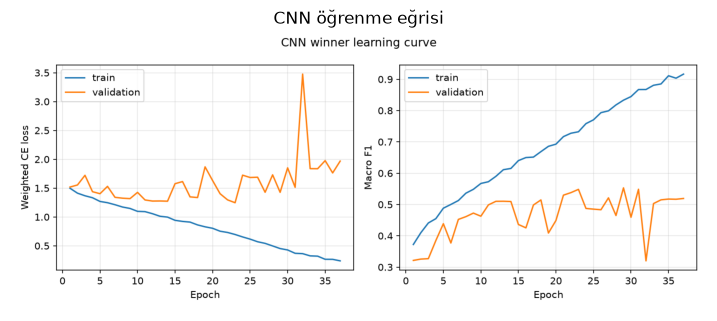

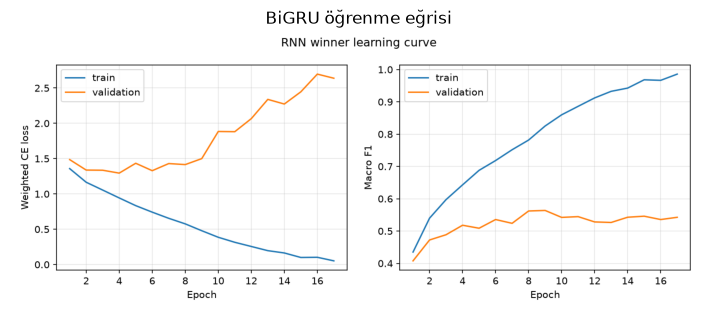

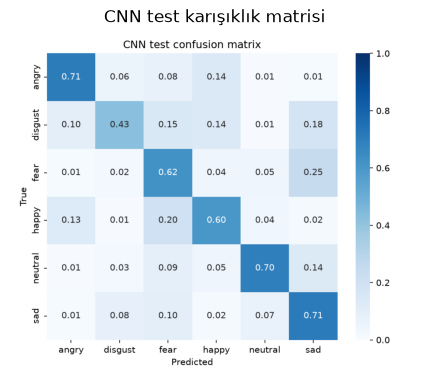

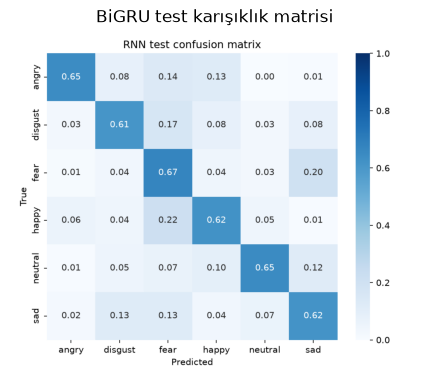

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

gorseller = [
    (CIKTI / 'cnn' / 'winner_learning_curve.png', 'CNN öğrenme eğrisi'),
    (CIKTI / 'rnn' / 'winner_learning_curve.png', 'BiGRU öğrenme eğrisi'),
    (CIKTI / 'cnn' / 'test_confusion_matrix.png', 'CNN test karışıklık matrisi'),
    (CIKTI / 'rnn' / 'test_confusion_matrix.png', 'BiGRU test karışıklık matrisi'),
]
for yol, baslik in gorseller:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.imshow(mpimg.imread(yol))
    ax.set_title(baslik)
    ax.axis('off')
    plt.show()

## 4. Geliştirme aşaması ve MELD genellemesi

In [5]:
for yontem in ('cnn', 'rnn'):
    ozet = json.loads((CIKTI / yontem / 'improvements_summary.json').read_text(encoding='utf-8'))
    print(f"=== {yontem.upper()} geliştirme (taban val macro-F1: {ozet['baseline_val_macro_f1']:.4f}) ===")
    display(pd.DataFrame(ozet['variants'])[['variant', 'val_macro_f1', 'delta_vs_winner']])

meld_yolu = Path('final/outputs/meld/summary.json')
if meld_yolu.is_file():
    meld = json.loads(meld_yolu.read_text(encoding='utf-8'))
    print('=== MELD (ortak 6 sınıf, konuşmacı-bağımsız) ===')
    display(pd.DataFrame([
        {'model': m, 'test doğruluk': round(meld[m]['test']['accuracy'], 4),
         'test dengeli doğruluk': round(meld[m]['test']['balanced_accuracy'], 4),
         'test macro-F1': round(meld[m]['test']['macro_f1'], 4)}
        for m in ('cnn', 'rnn') if m in meld
    ]))

=== CNN geliştirme (taban val macro-F1: 0.5531) ===


,variant,val_macro_f1,delta_vs_winner
0,specaugment,0.560588,0.007508
1,specaugment_light,0.545329,-0.007751


=== RNN geliştirme (taban val macro-F1: 0.5638) ===


,variant,val_macro_f1,delta_vs_winner
0,attention_pooling,0.554205,-0.009609
1,feature_noise,0.560166,-0.003648
2,attention_plus_noise,0.559695,-0.004120


=== MELD (ortak 6 sınıf, konuşmacı-bağımsız) ===


,model,test doğruluk,test dengeli doğruluk,test macro-F1
0,cnn,0.4431,0.2303,0.2184
1,rnn,0.3842,0.2036,0.1967


## 5. Demo — iyi/kötü örnekler

`final/demo_ornekleri/` dizininde test kümesinden seçilmiş 10 örnek var
(6 iyi: her duygudan bir, iki model de doğru; 4 kötü: modellerin yanıldığı).
Önce dizinden **rastgele** örnekler, ardından **adıyla verilen** bir girdi iki
yöntemden geçiriliyor. Komut satırı karşılığı: `python final/demo.py --rastgele 3`

In [6]:
from final.demo import DEFAULT_DIR, load_methods, run_demo
import random

yontemler = load_methods(device)
havuz = sorted(DEFAULT_DIR.glob('*.wav'))
rng = random.Random(42)
rastgele_secim = rng.sample(havuz, 3)
run_demo(rastgele_secim, yontemler, device)


1013_ITH_ANG_XX.wav   (gerçek: angry)


C:\Users\user\Desktop\470 proje\speech-emotion-recognition\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Yöntem 1 (CNN): angry  ✓   (angry=1.00, fear=0.00, disgust=0.00)


  Yöntem 2 (BiGRU): angry  ✓   (angry=1.00, disgust=0.00, fear=0.00)

1013_IEO_ANG_MD.wav   (gerçek: angry)
  Yöntem 1 (CNN): angry  ✓   (angry=0.96, happy=0.02, fear=0.02)
  Yöntem 2 (BiGRU): fear  ✗   (fear=0.41, angry=0.40, happy=0.10)

1036_ITH_NEU_XX.wav   (gerçek: neutral)
  Yöntem 1 (CNN): neutral  ✓   (neutral=0.86, happy=0.08, disgust=0.05)
  Yöntem 2 (BiGRU): neutral  ✓   (neutral=0.96, sad=0.02, angry=0.01)


In [7]:
# Adıyla/yoluyla verilen girdi (yönerge 8. bölüm)
run_demo([Path('final/demo_ornekleri/1013_TIE_DIS_XX.wav')], yontemler, device)


1013_TIE_DIS_XX.wav   (gerçek: disgust)
  Yöntem 1 (CNN): neutral  ✗   (neutral=0.30, happy=0.24, disgust=0.20)
  Yöntem 2 (BiGRU): fear  ✗   (fear=0.41, happy=0.17, neutral=0.15)


---
**Özet:** Geçerleme temelli seçim, kaydedilen modellerle birebir yeniden üretilebilen
test sonuçları (Yöntem 1: %62,9 / Yöntem 2: %63,8 doğruluk), geliştirme aşamasının
olumlu-olumsuz bulguları ve iki yöntemi karşılaştıran çalışır demo yukarıda tek
defterde toplanmıştır.